POC for RMS VAD

In [3]:
# Imports
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

from faster_whisper import vad

In [5]:
from faster_whisper.vad import VadOptions

def get_speech_timestamps_rms(
    audio: np.ndarray,
    vad_options: VadOptions = None,
    window_size_samples = 512,
    sampling_rate: int = 16000,
    **kwargs,
) -> list[dict]:
    """This method is used for splitting long audios into speech chunks using silero VAD.

    Args:
      audio: One dimensional float array.
      vad_options: Options for VAD processing.
      sampling rate: Sampling rate of the audio.
      kwargs: VAD options passed as keyword arguments for backward compatibility.

    Returns:
      List of dicts containing begin and end samples of each speech chunk.
    """
    if vad_options is None:
        vad_options = VadOptions(**kwargs)

    onset = vad_options.onset
    min_speech_duration_ms = vad_options.min_speech_duration_ms
    max_speech_duration_s = vad_options.max_speech_duration_s
    min_silence_duration_ms = vad_options.min_silence_duration_ms
    speech_pad_ms = vad_options.speech_pad_ms
    min_speech_samples = sampling_rate * min_speech_duration_ms / 1000
    speech_pad_samples = sampling_rate * speech_pad_ms / 1000
    max_speech_samples = (
        sampling_rate * max_speech_duration_s
        - window_size_samples
        - 2 * speech_pad_samples
    )
    min_silence_samples = sampling_rate * min_silence_duration_ms / 1000
    min_silence_samples_at_max_speech = sampling_rate * 98 / 1000

    audio_length_samples = len(audio)

    rms = librosa.feature.rms(y=audio, frame_length=2048, hop_length=window_size_samples)[0]

    triggered = False
    speeches = []
    current_speech = {}
    offset = vad_options.offset

    # to save potential segment end (and tolerate some silence)
    temp_end = 0
    # to save potential segment limits in case of maximum segment size reached
    prev_end = next_start = 0

    # Create speech segments using onset and offset thresholds
    # Merging to avoid minimum silence duration
    for i, speech_prob in enumerate(rms):
        if (speech_prob >= onset) and temp_end:
            temp_end = 0
            if next_start < prev_end:
                next_start = window_size_samples * i

        if (speech_prob >= onset) and not triggered:
            triggered = True
            current_speech["start"] = window_size_samples * i
            continue

        # Switch off if current segment longer than max_speech_duration_s
        if (
            triggered
            and (window_size_samples * i) - current_speech["start"] > max_speech_samples
        ):
            if prev_end:
                current_speech["end"] = prev_end
                speeches.append(current_speech)
                current_speech = {}
                # previously reached silence (< neg_thres) and is still not speech (< thres)
                if next_start < prev_end:
                    triggered = False
                else:
                    current_speech["start"] = next_start
                prev_end = next_start = temp_end = 0
            else:
                current_speech["end"] = window_size_samples * i
                speeches.append(current_speech)
                current_speech = {}
                prev_end = next_start = temp_end = 0
                triggered = False
                continue

        # switch off if prob goes below offset and
        # and has been for longer than min_silence_duration_ms
        if (speech_prob < offset) and triggered:
            if not temp_end:
                temp_end = window_size_samples * i
            # condition to avoid cutting in very short silence
            if (window_size_samples * i) - temp_end > min_silence_samples_at_max_speech:
                prev_end = temp_end
            if (window_size_samples * i) - temp_end < min_silence_samples:
                continue
            else:
                current_speech["end"] = temp_end
                # Add the chunk if it's longer than min_speech_duration_ms
                if (
                    current_speech["end"] - current_speech["start"]
                ) > min_speech_samples:
                    speeches.append(current_speech)
                current_speech = {}
                prev_end = next_start = temp_end = 0
                triggered = False
                continue

    # special handling for last chunk
    if (
        current_speech
        and (audio_length_samples - current_speech["start"]) > min_speech_samples
    ):
        current_speech["end"] = audio_length_samples
        speeches.append(current_speech)

    # Add speech_pad_ms to start of first chunk and end of last chunk
    for i, speech in enumerate(speeches):
        if i == 0:
            speech["start"] = int(max(0, speech["start"] - speech_pad_samples))
        if i != len(speeches) - 1:
            silence_duration = speeches[i + 1]["start"] - speech["end"]
            if silence_duration < 2 * speech_pad_samples:
                speech["end"] += int(silence_duration // 2)
                speeches[i + 1]["start"] = int(
                    max(0, speeches[i + 1]["start"] - silence_duration // 2)
                )
            else:
                speech["end"] = int(
                    min(audio_length_samples, speech["end"] + speech_pad_samples)
                )
                speeches[i + 1]["start"] = int(
                    max(0, speeches[i + 1]["start"] - speech_pad_samples)
                )
        else:
            speech["end"] = int(
                min(audio_length_samples, speech["end"] + speech_pad_samples)
            )

    return speeches


def merge_segments(segments_list, max_length_s, sampling_rate: int = 16000):
    if not segments_list:
        return []

    curr_end = 0
    seg_idxs = []
    merged_segments = []
    chunk_length = max_length_s * sampling_rate

    curr_start = segments_list[0]["start"]

    for idx, seg in enumerate(segments_list):
        if seg["end"] - curr_start > chunk_length and curr_end - curr_start > 0:
            merged_segments.append(
                {
                    "start": curr_start,
                    "end": curr_end,
                    "segments": seg_idxs,
                }
            )
            curr_start = seg["start"]
            seg_idxs = []
        curr_end = seg["end"]
        seg_idxs.append((seg["start"], seg["end"]))
    # add final
    merged_segments.append(
        {
            "start": curr_start,
            "end": curr_end,
            "segments": seg_idxs,
        }
    )
    return merged_segments


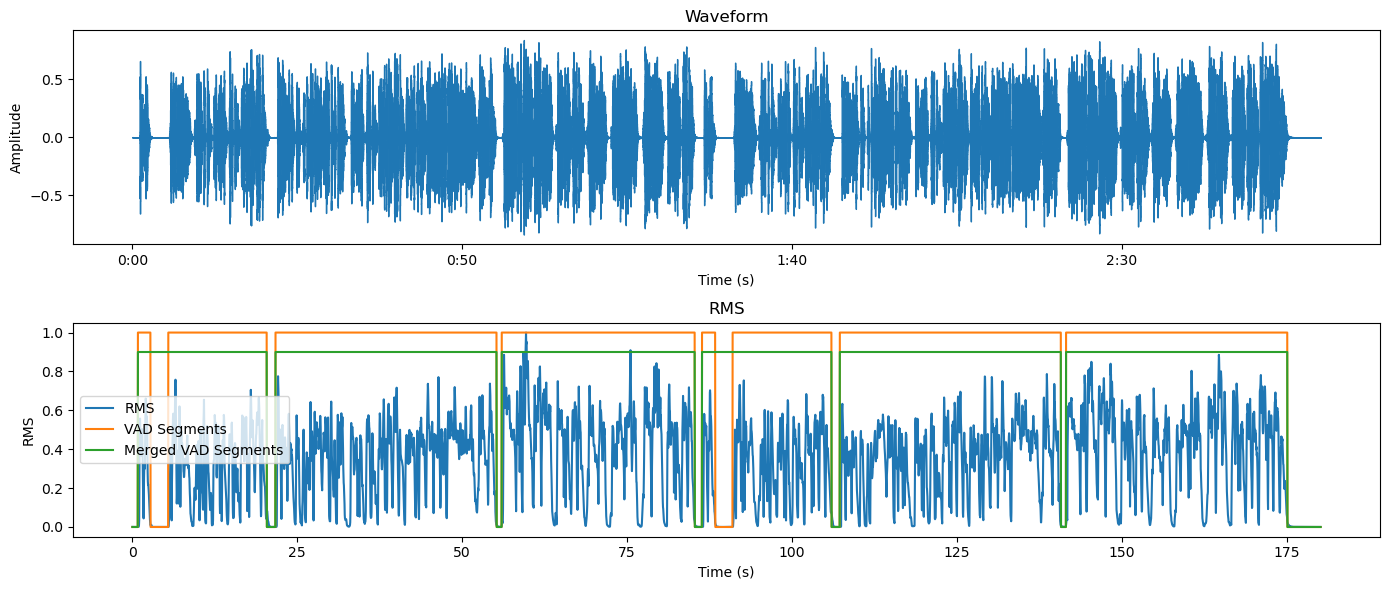

In [ ]:
# Load the audio file
vocals_fn = "../rsc/oyeme_tiburon.mp3"
# vocals_fn = "../build/e1_demucs/preproc/Avercage_-_Embers_jam-alt_vocals.mp3"
# vocals_fn = "../build/e1_demucs/preproc/Tom_Orlando_-_The_One__feat._Tina_G__jam-alt_vocals.mp3"
y, sr = librosa.load(vocals_fn, sr=16000)
window_size_samples=512

# Calculate the RMS
rms = librosa.feature.rms(y=y, frame_length=2048, hop_length=window_size_samples)[0]
rms = rms / np.max(rms)

# Calculate the speech segments
vad_options = VadOptions(
    onset=0.05,
    offset=0.05*0.9,
    min_speech_duration_ms=0,
    max_speech_duration_s=30,
    min_silence_duration_ms=1000,
    speech_pad_ms=200
)
speeches = get_speech_timestamps_rms(audio=y, vad_options=vad_options, sr=sr)
speech_on = np.zeros(len(rms))
max_rms = np.max(rms)
for speech in speeches:
    speech_on[speech["start"]//window_size_samples:speech["end"]//window_size_samples] = max_rms

merged_speeches = merge_segments(speeches, max_length_s=30, sampling_rate=sr)
merged_speech_on = np.zeros(len(rms))
for speech in merged_speeches:
    merged_speech_on[speech["start"]//window_size_samples:speech["end"]//window_size_samples] = max_rms * 0.9

# Create a figure and axis objects
fig, ax = plt.subplots(2, 1, figsize=(14, 6))

# Plot the waveform
librosa.display.waveshow(y, sr=sr, ax=ax[0])
ax[0].set(title='Waveform', xlabel='Time (s)', ylabel='Amplitude')

# Plot the RMS
frames = range(len(rms))
t = librosa.frames_to_time(frames, sr=sr)
ax[1].plot(t, rms, label='RMS')
ax[1].plot(t, speech_on, label="VAD Segments")
ax[1].plot(t, merged_speech_on, label="Merged VAD Segments")
ax[1].set(title='RMS', xlabel='Time (s)', ylabel='RMS')
ax[1].legend()

plt.tight_layout()
plt.show()